# DS-поток, весна 2025
## Задание ADL.3
### LLM, Alignment.

**Правила:**

* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Выполненную работу нужно отправить телеграм-боту `@miptstats_ds24_bot`. Для начала работы с ботом каждый раз отправляйте `/start`. Дождитесь подтверждения от бота, что он принял файл. Если подтверждения нет, то что-то не так. **Работы, присланные иным способом, не принимаются.**
* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Прислать нужно **ноутбук в формате `ipynb`**.
* Следите за размером файлов. **Бот не может принимать файлы весом более 20 Мб.** Если файл получается больше, заранее разделите его на несколько.
* Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания все участники списывания получат штраф.**
* Решения, размещенные на каких-либо интернет-ресурсах, не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Для выполнения задания используйте этот ноутбук в качестве основы, ничего не удаляя из него. Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.
* Если код будет не понятен проверяющему, оценка может быть снижена.
* Никакой код из данного задания при проверке запускаться не будет. *Если код студента не выполнен, недописан и т.д., то он не оценивается.*
* В каждой задаче не забывайте делать **пояснения и выводы**.
* **Код из рассказанных на занятиях ноутбуков** можно использовать без ограничений.

**Баллы за задание:**

* Задача 1 &mdash; 40 баллов;
* Задача 2 &mdash; 60 баллов.

<b><font size="5">Дорешка:</font></b>

* <b><font size="4">Задача 2</font></b>
  * <b><font color="#00b565" size="3">Запустил клетки</font></b>

In [1]:
%%capture
!pip install --no-deps bitsandbytes accelerate xformers==0.0.29.post3 peft trl==0.15.2 triton cut_cross_entropy unsloth_zoo
!pip install sentencepiece protobuf datasets huggingface_hub hf_transfer
!pip install --no-deps unsloth
!pip install --pre torch torchvision -f https://download.pytorch.org/whl/nightly/cu110/torch_nightly.html -U
!pip install -U vllm --pre --extra-index-url https://wheels.vllm.ai/nightly

In [2]:
import json

import torch
import unsloth
import numpy as np
import pandas as pd

from trl import (
    SFTTrainer,
    DataCollatorForCompletionOnlyLM
)

from datasets import Dataset, load_dataset
from transformers import (
    TrainingArguments,
    AutoModelForCausalLM,
    AutoTokenizer, 
    LlamaTokenizerFast
)
from unsloth import (
    FastLanguageModel,
    is_bfloat16_supported
)
from unsloth.chat_templates import get_chat_template

from vllm import LLM, SamplingParams
from vllm.sampling_params import GuidedDecodingParams

import matplotlib.pyplot as plt
from collections import Counter

import torch
from torch.utils.data import DataLoader
import random

from tqdm.notebook import tqdm
import os
import gc
import logging


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
os.environ['MASTER_ADDR'] = "localhost"
os.environ['MASTER_PORT'] = '29500'
os.environ["VLLM_CONFIGURE_LOGGING"] = "0"
logging.disable(logging.CRITICAL)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


2025-05-08 21:21:37.998134: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746739298.187996      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746739298.242817      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


🦥 Unsloth Zoo will now patch everything to make training faster!
INFO 05-08 21:21:55 [importing.py:53] Triton module has been replaced with a placeholder.
INFO 05-08 21:21:55 [__init__.py:239] Automatically detected platform cuda.


---
### Задача 1. 

В этой задаче вам предложено провести сравнительное исследование, оценив эффективность нескольких LLM в различных форматах: zero-/few-shot для задачи анализа тональности текста на датасете отзывов IMDB.

---
**Форматы zero-/few-shot**

Современные большие языковые модели (LLM), обученные следовать инструкциям, позволяют решать задачи классификации, если правильно оформить запрос к ним. Подготовку надежной инструкции для решения задачи иногда еще называют промптингом. Подробнее можно почитать <a href="https://docs.mistral.ai/guides/prompting_capabilities/" target="_top">здесь</a> или <a href="https://huggingface.co/docs/transformers//tasks/prompting" target="_top">здесь</a>, или самостоятельно обсудить с LLM!


Рассмотрим два довольно популярных подхода.
* *Zero-Shot* \
  Модель выполняет задачу, опираясь только на инструкцию, без дополнительных примеров. Допустим вы можете сформулировать запрос к модели так:
  ```
  Определи, POSITIVE или NEGATIVE тон у этого текста: {текст}.
  ```
  <br>
* *Few-Shot* \
  Модель получает $k$ **примеров вместе с ответом** перед основным запросом. Это позволяет познакомить модель, например, с форматом ответа и показать какие-то паттерны через демонстрацию. \
  Рассмотрим возможный `2-shot` формат. Он предполагает демонстрацию на **двух примерах вместе с референсным ответом**. Третьим запросом будет идти целевой:

  ```
  Пример 1: "Фильм ужасен..." → NEGATIVE
  Пример 2: "Это шедевр!" → POSITIVE
  Задача: Определи тональность для "{текст}".
  ```

Обратим внимание, что Few-Shot-подход можно реализовать разными способами в зависимости от API или чат-интерфейса модели.

1. Использовать системный промпт и указать инструкцию **вместе с примерами** прямо там.

```
system_prompt = """
Ты классифицируешь тональность текста. Вот примеры:  
- "Фильм ужасен..."\nОтвет: NEGATIVE  
- "Это шедевр!"\nОтвет: POSITIVE  
Отвечай только метками POSITIVE/NEGATIVE.  
"""
```

В таком случае в `user`-реплике будет содержаться только текст целевого отзыва. При этом можно поступить иначе и использовать, например, стандартный системный промпт, рекомендованный разработчиками модели. Тогда инструкцию и few-shot примеры можно поместить сразу в `user`-реплику.


2. Используя чат-шаблон (chat-template). Тогда k-shot вариант можно реализовать следующим образом:

```
{"role": "system", "content": "Ты классифицируешь тональность текста."},  # Общая инструкция в сис. промпте, но можно и в user-реплику!
{"role": "user", "content": "Отзыв: 'Сюжет скучный...'\nОтвет:"},         # Пример 1
{"role": "assistant", "content": "NEGATIVE"},                             # Важно: ответ модели заполнен нами самостоятельно! Его можно взять из train-сета
...
{"role": "user", "content": "Отзыв: 'Лучший фильм года!'\nОтвет:"},       # Пример k
{"role": "assistant", "content": "POSITIVE"},                             # Ответ для примера k
{"role": "user", "content": "Отзыв: '{review}'\nОтвет:"}                  # Тут расположен целевой пример для прогона
```
В данном случае $k$ примеров, которые можно взять из обучающей выборки, вместе с ответами и примером для инференса принудительно помещены в историю диалога. Модель, генерируя след. реплику, выдаст нам ответ на задачу, а примеры в контексте позволят лучше следовать формату ответа и потенциально повысят итоговое качество.

Выбор стратегии, вообще говоря, зависит от пользователя и ограничений модели. Например, некоторые модели могут не поддерживать системный промпт.

---

Итак, вам требуется применить **две** open-source LLM для задачи sentiment analysis на датасете IMDB и сравнить их производительность в режимах zero- и few-shot на **валидационной подвыборке размера 2k сэмплов.**

Для few-shot используйте $k=5$ примеров, которые возьмите случайным образом из обучающей выборки. Выбор конкретного формата из описанных выше остается на вашей стороне :)


**Подумайте**, должны ли few-shot примеры быть сбалансированы, то есть содержать приблизительно одинаковое кол-во позитивных и негативных примеров? Какие стратегии выбора фьюшот примеров вы можете предложить?

В качестве LLM используйте `Qwen/Qwen2.5-3B` и `unsloth/Llama-3.2-1B-Instruct` с HuggingFace. Попробуйте **поэкспериментировать с различными вариантами промпта**. Можете взять за основу пример с семинара и воспользоваться ИИ-инструментами для его усовершенствования. Сравните результат с моделью на базе RNN, с которой вы имели дело ранее.

Представьте результат в виде аккуратной таблицы, в которой укажите модель вместе с используемым форматом (zero-/few-shot), а также итоговую точность (accuracy). Сделайте выводы.

*Замечание* \
*Для инференса рекомендуется использовать `vLLM.` Метод `.chat` может обрабатывать батч запросов, что позволит ускорить вычисления и повысить утилизацию GPU.*
```
batch_indices = range(batch_start, batch_start + batch_size)
batch_data = data.select(batch_indices)
conversations = [[{"role": "user", "content": format_text_request(review)}] for review in batch_data["review"]]
outputs = model.chat(conversations, ...)
```

In [3]:
data = load_dataset(
    "scikit-learn/imdb", split="train"
).train_test_split(test_size=0.2, seed=42)
data

README.md:   0%|          | 0.00/1.22k [00:00<?, ?B/s]

IMDB%20Dataset.csv:   0%|          | 0.00/66.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['review', 'sentiment'],
        num_rows: 40000
    })
    test: Dataset({
        features: ['review', 'sentiment'],
        num_rows: 10000
    })
})

In [4]:
validation_subsample = data["test"][:2000]

In [5]:
def get_one_shot_accuracy(
    train_dataset,
    valid_loader,
    model,
    k: int = 1,
    developer_mode: bool = False
):
    guided = GuidedDecodingParams(choice=["POSITIVE", "NEGATIVE"])
    sampling = SamplingParams(guided_decoding=guided, temperature=0.0)

    dataset_size = len(train_dataset)
    all_preds = []
    all_labels = []

    for batch_idx, batch in enumerate(tqdm(valid_loader, desc="Evaluating")):
        reviews = batch["review"]
        labels  = batch["sentiment"]

        conversations = []
        for review in reviews:
            if k > 0:
                # k-shot
                indices = random.sample(range(dataset_size), k)
                shots = ""
                for idx_i, idx in enumerate(indices):
                    demo_review = train_dataset["review"][idx]
                    demo_label = train_dataset["sentiment"][idx]
                    demo_label_str = (
                        "POSITIVE"
                        if str(demo_label).strip().lower() in ("positive", "true", "1")
                        else "NEGATIVE"
                    )
                    shots += (
                        f"Example {idx_i + 1}:\n"
                        f"Review: {demo_review}\n"
                        f"Sentiment: {demo_label_str}\n\n"
                    )
                prompt = (
                    shots +
                    "Now classify this review as POSITIVE or NEGATIVE:\n"
                    f"Review: {review}"
                )
            else:
                # zero-shot
                prompt = (
                    "Classify this review as POSITIVE or NEGATIVE:\n"
                    f"Review: {review}"
                )

            conversations.append([{"role": "user", "content": prompt}])

        chat_results = model.chat(
            messages=conversations,
            sampling_params=sampling
        )

        for chat_out, true_label in zip(chat_results, labels):
            text = chat_out.outputs[0].text.strip().lower()
            pred_label = "positive" if "positive" in text else "negative"

            all_preds.append(pred_label == "positive")
            all_labels.append(str(true_label).strip().lower() in ("positive", "true", "1"))

        if developer_mode:
            break

    accuracy = float(np.mean([p == t for p, t in zip(all_preds, all_labels)]))
    return accuracy


In [6]:
validation_data = [
    {"text": text, "label": label}
    for text, label in zip(validation_subsample["review"], validation_subsample["sentiment"])
]

# collate_fn — тот же, подходит
def collate_fn(batch):
    return {
        "review": [item["text"] for item in batch],
        "sentiment": [item["label"] for item in batch],
    }

# Теперь создаем DataLoader
valid_loader = DataLoader(
    validation_data,
    batch_size=16,
    shuffle=False,
    collate_fn=collate_fn
)

In [7]:
models = ["Qwen/Qwen2.5-3B-Instruct", "unsloth/Llama-3.2-1B-Instruct"]
names = ["qwen", "llama"]

In [8]:
results = []

for model_name, short_name in zip(models, names):
    print(f"Running for model: {model_name}")
    
    torch.cuda.empty_cache()
    
    VLLM_CONFIGURE_LOGGING = 0
    model = LLM(
        model=model_name,
        dtype="float16",
        tensor_parallel_size=1,
        enforce_eager=True,
    )

    print(f"{short_name} one shot")
    acc_one_shot = get_one_shot_accuracy(data["train"], valid_loader, model, k=0, developer_mode=False)

    print(f"{short_name} k shot")
    acc_k_shot = get_one_shot_accuracy(data["train"], valid_loader, model, k=5, developer_mode=False)

    results.append({
        "model": short_name,
        "one_shot": acc_one_shot,
        "k_shot": acc_k_shot
    })

    del model
    gc.collect()
    torch.cuda.empty_cache()

Running for model: Qwen/Qwen2.5-3B-Instruct


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

Processed prompts:   0%|          | 0/16 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Processed prompts:   0%|          | 0/16 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Processed prompts:   0%|          | 0/16 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Processed prompts:   0%|          | 0/16 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Processed prompts:   0%|          | 0/16 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

In [9]:
df = pd.DataFrame(results).set_index("model")
df

,one_shot,k_shot
model,,
qwen,0.902,0.8855
llama,0.493,0.5010


**Вывод**

Удивительно, zero-shot показал большую точность, хоть и на погрешность, чем few-shot, возмонжо это связано с тем что модель теряла контекст, а потому менее корректно отвечала на вопрос

Заметим, что llama совершенно не справилась с задачей, возможно это связано с тем, что она обучалась на слишком малом количестве русских текстов или слишком быстро теряла контекст.


<b><font color="#00b565" size="5">Запустил клетки</font></b>

<b><font color="#00b565" size="3">Замечание:</font></b> <i>Отсутствует вывод во всех клетках задачи</i>

---
### Задача 2.

В этой задаче вы разберете пример Supervised Fine-Tuning (SFT) для новой русскоязычной базовой модели, недавно выпущенной Яндексом. Подробнее о модели можно прочесть [здесь](https://habr.com/ru/companies/yandex/articles/895428/) и [здесь](https://habr.com/ru/companies/yandex/articles/885218/).

SFT (Supervised Fine-Tuning) в данном случае — это этап дообучения предварительно обученной языковой модели на большом наборе инструктивных данных, называемый также Instruction Finetuning. Мы будем учить LLM следовать указаниям пользователя, что критически важно для создания современных ассистентов и чат-ботов. На этапе SFT модель адптируется к конкретным задачам: генеративные ответы на вопросы, диалог с пользователям, задачи классификации и генерации кода, и т. д.


In [10]:
MODEL_NAME = "yandex/YandexGPT-5-Lite-8B-pretrain"
# Будем работать с небольшим контекстом в 2k токенов
# Современные модели обычно имеют контекст в 32k-128k токенов
# Некоторые техники позволяют добиться контекста ~1m токенов.
MAX_SEQ_LENGTH = 2048

Для начала загрузим датасет. Это смешанный набор инструктивных данных из разных источников с полезной мета-информацией. На этом датасете обучаются в том числе модели opensource-проекта [Сайга](t.me/saiga_igusev_bot).

In [11]:
dataset = load_dataset("IlyaGusev/saiga_scored")

README.md:   0%|          | 0.00/772 [00:00<?, ?B/s]

train.parquet:   0%|          | 0.00/115M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/41609 [00:00<?, ? examples/s]

Датасет достаточно большого размера, содержит информацию об источнике, языке диалога, а также полезные признаки в виде оценки тематики / сложности сэмпла, полученные с помощью более производительных LLM [(Sonnet, Opus)](https://habr.com/ru/companies/bothub/articles/823580/).

In [12]:
dataset

DatasetDict({
    train: Dataset({
        features: ['messages', 'source', 'opus_score', 'language', 'turns', 'sonnet_topic', 'sonnet_topic_explanation', 'sonnet_complexity', 'sonnet_complexity_explanation', 'is_bad_by_regex', 'score_explanation'],
        num_rows: 41609
    })
})

Посмотрим на какой-нибудь пример.

In [13]:
dataset["train"][1800]

{'messages': [{'content': 'как мне найти искусственный интеллект? который будет мне во всем помогать? ',
   'role': 'user'},
  {'content': 'Чтобы найти искусственный интеллект (ИИ), который будет вам во всем помогать, вам нужно определиться с тем, какие именно задачи вы хотите на него возложить. Искусственный интеллект может помогать в самых разных областях: от управления вашими ежедневными задачами до помощи в анализе данных или даже в обучении новым навыкам. Вот несколько шагов, которые помогут вам найти подходящего ИИ-помощника:\n\n1. **Определите свои потребности**: Прежде всего, вам нужно четко понять, для каких задач вы ищете ИИ. Это может быть что-то общее, например, управление задачами и напоминаниями, или что-то более специфическое, например, анализ больших объемов данных или автоматизация определенных процессов.\n\n2. **Исследуйте доступные варианты**: Существует множество ИИ-платформ и приложений, каждое из которых предлагает разные функции. Некоторые из наиболее популярных 

Вам предлагается поработать с подвыборкой из этого сета. Для этого проведите базовую аналитку: посмотрите на распр. по языкам, тематикам и сложности данных. Посчитайте базовые статистики (среднее, минимум и максимум) для реплик модели / длины диалога.
Учтите, что в большей степени нас интересуют инструкции и ответы на русском языке, небольшую аналитику можно провести для него отдельно. Не забывайте про аккуратность графиков.

Для начала посмотрим какой процент составляет русский язык.

In [14]:
def plot_language_distribution(languages, title="Распределение языков в выборке"):
    language_counts = Counter(languages)
    total = sum(language_counts.values())
    sorted_items = sorted(language_counts.items(), key=lambda x: x[1], reverse=True)

    labels = [
        lang if count / total >= 0.02 else ""
        for lang, count in sorted_items
    ]
    sizes = [count for _, count in sorted_items]

    def autopct_format(pct):
        return f'{pct:.1f}%' if pct >= 2 else ''

    plt.figure(figsize=(8, 8))
    plt.pie(sizes, labels=labels, autopct=autopct_format, startangle=140)
    plt.title(title)
    plt.axis("equal")
    plt.show()

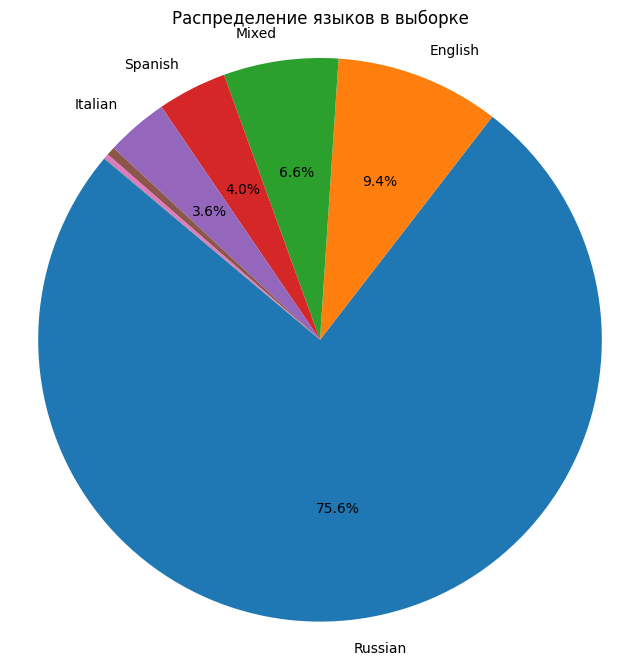

In [15]:
plot_language_distribution(dataset["train"]["language"])

Посмотрим на распределение сложности текстов.

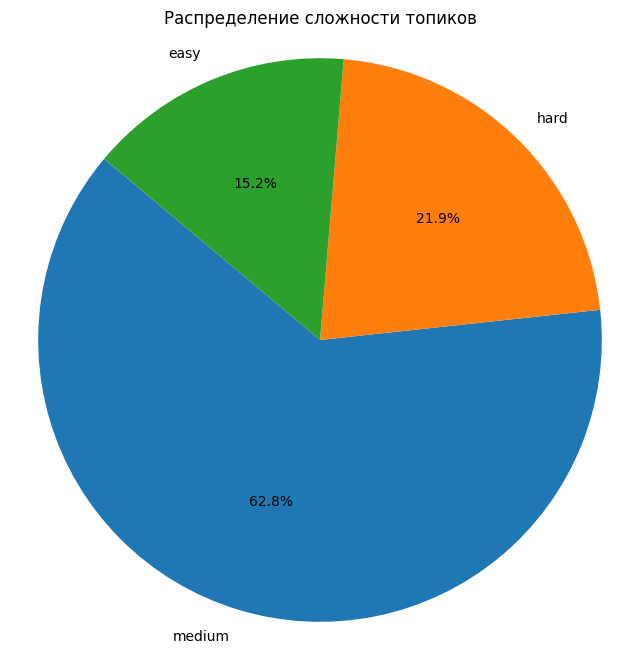

In [16]:
plot_language_distribution(dataset["train"]["sonnet_complexity"], title="Распределение сложности топиков")

Посмотрим на оценку opus

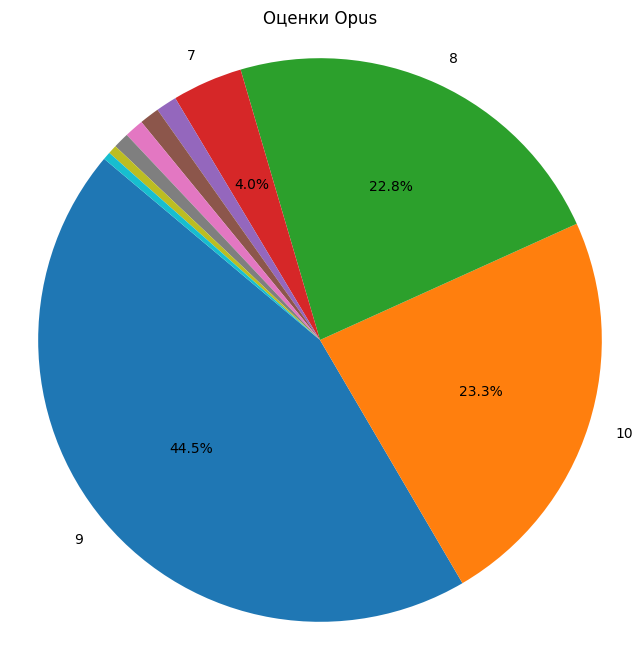

In [17]:
plot_language_distribution(dataset["train"]["opus_score"], title="Оценки Opus")

Посмотрим какой процент диалогов признан неудачным

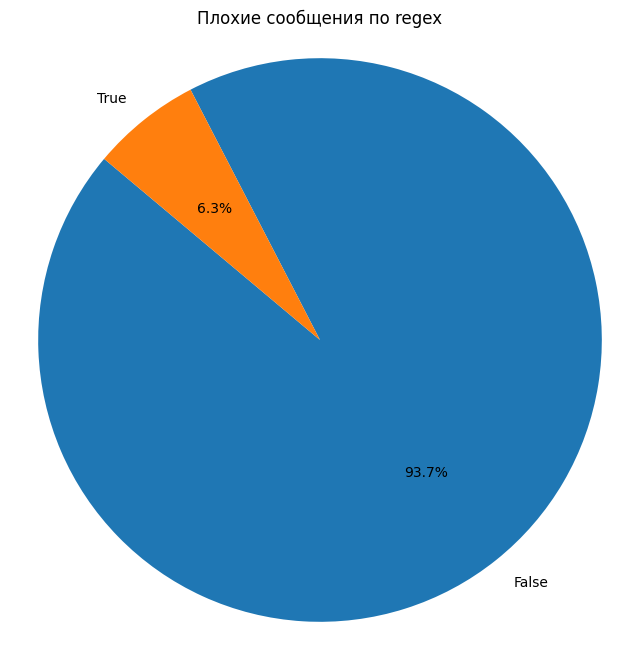

In [18]:
plot_language_distribution(dataset["train"]["is_bad_by_regex"], title="Плохие сообщения по regex")

Посмотрим на среднюю длину сообщения пользователя и бота

In [19]:
def plot_message_length_histogram(data):
    user_lengths = []
    bot_lengths = []

    for dialogue in data["train"]:
        for message in dialogue["messages"]:
            length = len(message["content"])
            if length > 10000:
                continue
            if message["role"] == "user":
                user_lengths.append(length)
            elif message["role"] == "bot":
                bot_lengths.append(length)

    plt.figure(figsize=(10, 6))
    plt.hist(user_lengths, bins=30, alpha=0.7, label="User", color="red", edgecolor='black')
    plt.hist(bot_lengths, bins=30, alpha=0.7, label="Bot", color="lightgreen", edgecolor='black')

    plt.title("Распределение длин сообщений пользователя и бота")
    plt.xlabel("Длина сообщения (в символах)")
    plt.ylabel("Частота")
    plt.xlim(0, 6000)
    plt.legend()
    plt.grid(True)

    # Устанавливаем xticks с дополнительными метками на 100, 500, 1000
    current_xticks = plt.xticks()[0]
    extra_ticks = [300, 500, 1000]
    all_ticks = sorted(set(current_xticks).union(extra_ticks))
    plt.xticks(all_ticks)

    plt.tight_layout()
    plt.show()

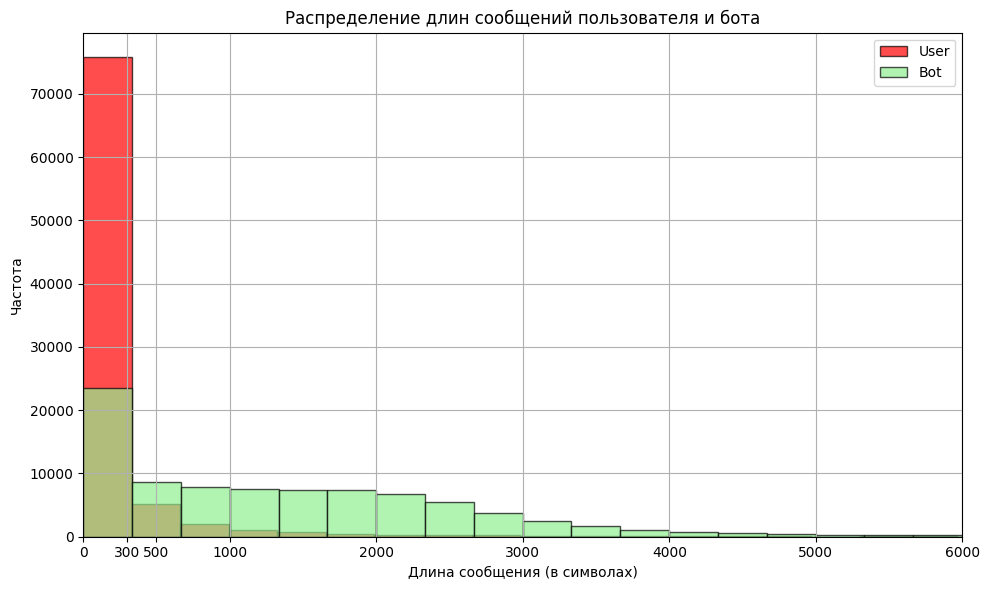

In [20]:
plot_message_length_histogram(dataset)

Исходя из проведенной аналитики попробуйте через различные эвристики отфильтровать датасет. При этом для простоты решения задачи важно будет оставить только одношаговые диалоги. В итоге будет достаточно 2k-3k качественных сэмплов.

In [21]:
def filter_function(x):
    if x["turns"] > 1:
        return False
    
    if x["language"] != "Russian":
        return False

    if x["is_bad_by_regex"]:
        return False

    if x["opus_score"] < 10:
        return False

    if any(len(msg["content"]) >= 4096 for msg in x["messages"]):
        return False

    if len(x["messages"]) != 2:
        return False
    if x["messages"][0]["role"] != "user" or x["messages"][1]["role"] != "bot":
        return False

    return True

In [22]:
filtered_data = dataset["train"].filter(filter_function)

Filter:   0%|          | 0/41609 [00:00<?, ? examples/s]

In [23]:
filtered_data.shape

(3158, 11)

In [24]:
filtered_data["messages"][0]

[{'content': 'Выразите численные значения на словесном уровне.\n\n45, 100, 123456',
  'role': 'user'},
 {'content': 'сорок пять, сто, сто двадцать три тысячи четыреста пятьдесят шесть',
  'role': 'bot'}]

Как вы могли заметить вместо привычного `assistant` в списке сообщений `messages` встречается роль `bot`. Давайте использовать более классический вариант.

In [25]:
def rename_bot_in_messages(example):
    for msg in example["messages"]:
        if msg["role"] == "bot":
            msg["role"] = "assistant"
    return example

filtered_data = filtered_data.map(rename_bot_in_messages)

Map:   0%|          | 0/3158 [00:00<?, ? examples/s]

In [26]:
filtered_data["messages"][0]

[{'content': 'Выразите численные значения на словесном уровне.\n\n45, 100, 123456',
  'role': 'user'},
 {'content': 'сорок пять, сто, сто двадцать три тысячи четыреста пятьдесят шесть',
  'role': 'assistant'}]

Теперь разберемся с токенизатором.

In [27]:
tokenizer = LlamaTokenizerFast.from_pretrained(MODEL_NAME, legacy=False)
tokenizer

tokenizer_config.json:   0%|          | 0.00/236 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/2.57M [00:00<?, ?B/s]

LlamaTokenizerFast(name_or_path='yandex/YandexGPT-5-Lite-8B-pretrain', vocab_size=129024, model_max_length=1000000000000000019884624838656, is_fast=True, padding_side='left', truncation_side='right', special_tokens={'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("<s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("
", rstrip=False, lstrip=False, single_word=False, normalized=False, special=False),
	4: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=False),
	5: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=False),
	6: AddedToken("[CLS]", rstrip=False, ls

С 128000 по 129024 токен находятся зарезервированные спец. токены. Они предварительно добавлены в токенизатор и эмбеддинг слой модели для удобства, но не участвовали в претрейне. Например спец. токены пригодятся нам, чтобы грамотно обучить модель следовать чат-шаблону. Можно использовать токены с 128000 включительно, поменяв представление `[SPEC_TOKEN_{IDX}]` из токенизатора на наболее привычный `<|start_header_id|>` и т. п.

**Важно:** Мы будем делать LoRA-обучение, исходные эмбеддинги трогать не будем, поэтому в случае добавления спец. токенов они останутся необучаемыми, что будет не совсем корректно. Поэтому в данном случае мы все так же будем использовать условный `<|start_header_id|>`, но токенизироваться он будет не в один спец. токен, а в несколько простых.

Будем использовать chat-template от серии моделей `llama-3`.

In [28]:
tokenizer = get_chat_template(
    tokenizer,
    chat_template="llama-3",
    # system_message= есть возможность задать системное сообщение
)

Model does not have a padding token! Will use pad_token = <unk>.


У нашего токенизатора появился чат-шаблон! Посмотрим на него. 

In [29]:
tokenizer.chat_template

"{{ bos_token }}{% for message in messages %}{% if message['role'] == 'user' %}{{ '<|start_header_id|>user<|end_header_id|>\n\n' + message['content'] | trim + '<|eot_id|>' }}{% elif message['role'] == 'assistant' %}{{ '<|start_header_id|>assistant<|end_header_id|>\n\n' + message['content'] | trim + '<|eot_id|>' }}{% else %}{{ '<|start_header_id|>' + message['role'] + '<|end_header_id|>\n\n' + message['content'] | trim + '<|eot_id|>' }}{% endif %}{% endfor %}{% if add_generation_prompt %}{{ '<|start_header_id|>assistant<|end_header_id|>\n\n' }}{% endif %}"

Еще раз обратим внимание, `<|start_header_id|>` и похожие токены участвуют в шаблоне, но они НЕ добавлены как спец. токены, поэтому токенизируются в несколько токенов, как обычный текст.

In [30]:
tokenizer("<|start_header_id|>assistant<|end_header_id|>\n\n")

{'input_ids': [1, 1078, 125853, 4991, 125865, 8264, 125865, 367, 73136, 108651, 125906, 125853, 617, 125865, 8264, 125865, 367, 73136, 3, 3], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

Посмотрим на пример применения чат-шаблона. Обучать модель будем предсказывать только `assistant`-реплики модели.

In [31]:
chat_template_sample = tokenizer.apply_chat_template(filtered_data[1800]["messages"], tokenize=False)
chat_template_sample

'<s><|start_header_id|>user<|end_header_id|>\n\nкакая антилопа самая красивая<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\nОпределить, какая антилопа самая красивая, довольно сложно, так как восприятие красоты субъективно и зависит от личных предпочтений каждого человека. Существует множество видов антилоп, каждый из которых обладает уникальными особенностями. Некоторые из них выделяются своим окрасом, формой рогов или грациозностью форм. Вот несколько примеров антилоп, которые часто считаются красивыми:\n\n1. **Гну** - хотя их внешний вид может показаться необычным, динамичные миграции гну через Африканские равнины являются впечатляющим зрелищем.\n\n2. **Импала** - эти антилопы известны своими изящными линиями тела и способностью совершать высокие прыжки. Их грациозность и красивый окрас делают их одними из самых фотогеничных антилоп.\n\n3. **Куду** (большой и малый) - обладают впечатляющими спиралевидными рогами и красивым окрасом. Особенно мужские особи выглядят внушите

Теперь загрузим модель

In [32]:
# Будем использовать квантизацию в 4бита, подробнее, что это значит
# мы узнаем на след. занятии
dtype = None
load_in_4bit = True

# Загрузка модели через знакомый метод .from_pretrained
model, unsloth_tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=dtype,
    load_in_4bit=load_in_4bit,
)

==((====))==  Unsloth 2025.4.7: Fast Llama patching. Transformers: 4.51.1. vLLM: 0.8.5.post1.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 7.5. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.29.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

model-00001-of-00004.safetensors:   0%|          | 0.00/4.98G [00:00<?, ?B/s]

model-00002-of-00004.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

model-00003-of-00004.safetensors:   0%|          | 0.00/4.92G [00:00<?, ?B/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/1.17G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/236 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/2.57M [00:00<?, ?B/s]

yandex/YandexGPT-5-Lite-8B-pretrain does not have a padding token! Will use pad_token = <unk>.


Важно помнить, что это пока базовая модель, она просто продолжает текст!

In [33]:
prompt = "План изучения машинного обучения:"
device = torch.device("cuda:0")
tokenized_prompt = tokenizer(prompt, return_tensors="pt").to(device)
# Посмотрим на генерацию
outputs = model.generate(**tokenized_prompt,
                         do_sample=True,
                         temperature=0.3,
                         max_new_tokens=128,
                         # Используем KV-cache, а не пересчитываем векторы key/value
                         use_cache=True)
tokenizer.batch_decode(outputs)[0]

'<s> План изучения машинного обучения:\n\n1. Введение в машинное обучение\n\n2. Классификация алгоритмов машинного обучения\n\n3. Применение машинного обучения в различных областях\n\n4. Основные понятия машинного обучения\n\n5. Методы обучения с учителем\n\n6. Методы обучения без учителя\n\n7. Методы обучения с подкреплением\n\n8. Методы оптимизации в машинном обучении\n\n9. Методы кластеризации в машинном обучении\n\n10. Методы регрессии в машинном обучении\n\n11. Методы классификации в машинном обучении\n\n12. Методы ассоциативного анализа в машинном обучении\n\n13. Методы обработки естественного языка'

Теперь добавим обучаемые LoRA-адаптеры. Полноценный SFT в рамках Colab'a будет сделать сложно, поэтому обойдемся peft-методом, функционал есть прямо в `unsloth`!

In [34]:
model = FastLanguageModel.get_peft_model(
    model,
    # Знакомые гиперпараметры LoRA
    r=8,
    target_modules=[
        "q_proj",    # Attention
        "k_proj",    # Attention
        "v_proj",    # Attention
        "o_proj",    # Attention
        "gate_proj", # MLP
        "up_proj",   # MLP
        "down_proj", # MLP
    ],
    lora_alpha=16,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth", # Подробнее на след. занятии
    random_state=3407,
    use_rslora=False,  # Без rank stabilized LoRA
    loftq_config=None, # And LoftQ
)

Напишем функцию для применения чат-шаблона к каждому сэмплу. Учтите, что токенизировать текст на этом этапе не стоит, добавлять спец. токены и `generation_prompt` тоже. Важно грамотно указать аргументы `.apply_chat_template(...)`.

In [35]:
def formatting_prompts_func(examples):
    convos = examples["messages"]
    texts = [tokenizer.apply_chat_template(
        msg,
        tokenize=False,            
        add_generation_prompt=False
    ) for msg in convos]
    return {
        # Отформатированные тексты сообщений для последующей токенизации
        "text" : texts
    }

filtered_data = filtered_data.map(formatting_prompts_func, batched=True)

Map:   0%|          | 0/3158 [00:00<?, ? examples/s]

Посмотрим на получившийся пример. В поле `text` должно быть что-то похожее:
```
<s><|start_header_id|>user<|end_header_id|>\n\nкрасивые места ульяновска<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\nУльяновск — город ....<|eot_id|>
```

In [36]:
filtered_data[5]["text"]

'<s><|start_header_id|>user<|end_header_id|>\n\nСеть задана IP\u2060-\u2060адресом 172.16.168.0 и маской сети 255.255.248.0.<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\nДанная сеть задана IP-адресом **172.16.168.0** с маской подсети **255.255.248.0**. Рассмотрим основные характеристики этой сети:\n\n### 1. Представление в CIDR нотации\n- **CIDR:** 172.16.168.0/21\n\n### 2. Маска подсети\n- **Десятичная форма:** 255.255.248.0\n- **Двоичная форма:** 11111111.11111111.11111000.00000000\n\n### 3. Количество адресов в сети\n- **Общее количество адресов:** 2^(32-21) = 2¹¹ = 2048 адресов\n- **Доступных для хостов:** 2046 адресов (за вычетом сетевого и широковещательного адресов)\n\n### 4. Адреса сети и широковещательный адрес\n- **Сетевой адрес:** 172.16.168.0\n- **Широковещательный адрес:** 172.16.175.255\n\n### 5. Диапазон доступных IP-адресов для хостов\n- **Первый доступный адрес:** 172.16.168.1\n- **Последний доступный адрес:** 172.16.175.254\n\n### 6. Детали подсети\n- **И

Теперь зададим data-collator. Этот объект подготавливает тензоры перед форвародом. Обратите внмиание, мы будем использовать `DataCollatorForCompletionOnlyLM`. Он позволяет обучаться только ответах модели, то есть на токенах после `assistant<|end_header_id|>\n\n`. 

In [37]:
tokenizer.add_bos_token = False # при токенизации не добавляем bos, т.к. он есть в чат-шаблоне и уже находится в сэмплах.
# Предварительно токенизированная часть  assistant<|end_header_id|>\n\n
tokenized_assistant_response_template = [108651, 125906, 125853, 617, 125865, 8264, 125865, 367, 73136, 3, 3]
# Обучаться будем только на ответах модели, то есть токенах после assistant<|end_header_id|>\n\n
collator = DataCollatorForCompletionOnlyLM(
    # явно указываем начало assistant-реплики, до нее включительно будет стоять -100 для подсчет Cross-Entropy
    response_template=tokenized_assistant_response_template,
    tokenizer=tokenizer
)

Зададим трейнер.

In [38]:
trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=filtered_data,
    # Передаем поле, в котором отформатированные сообщения
    # Токенизацию выполнит trainer
    dataset_text_field="text",
    max_seq_length=MAX_SEQ_LENGTH,
    dataset_num_proc=2,
    data_collator=collator,
    packing=False,
    args = TrainingArguments(
        per_device_train_batch_size=2,
        # На след. занятии поговорим об этом
        gradient_accumulation_steps=4,
        # Используем небольшой warmup
        warmup_steps=5,
        # Для знакомства модели с SFT форматом будет достаточно
        max_steps=10,
        learning_rate=1e-4,
        # На след. занятии поговорим об этом
        fp16=True,
        logging_steps=1,
        # На след. занятии поговорим об этом
        optim="adamw_8bit",
        # Регуляризация
        weight_decay=0.01,
        # Линейный шедулер
        lr_scheduler_type="linear",
        seed=3407,
        output_dir="outputs",
        report_to="none"
    ),
)

Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/3158 [00:00<?, ? examples/s]

Посмотрим, как работает `DataCollatorForCompletionOnlyLM`. Обратите внимание, что в `labels` имеется некоторый префикс из `-100`. Так мы обучаем модель предсказывать токены реплики модели, игнорируя при подсчете лосса запрос юзера и системный промпт. При этом, в наших данных сейчас только одношаговые диалоги. В более продвинутом случае (многошаговые диалоги) процесс маскирования реплик модели был бы немного сложнее.

In [39]:
collator([trainer.train_dataset[7]["input_ids"]])

{'input_ids': tensor([[     1, 125906, 125853,   4991, 125865,   8264, 125865,    367,  73136,
            2478, 125906, 125853,    617, 125865,   8264, 125865,    367,  73136,
               3,      3,  29422,    618, 123111,   4793,   3282,  98027,    765,
           13443, 125820,   7624,   7160,   1046,  44968,    286,  60779, 125820,
            2261,  65743, 125827,    470,   1209,   7440,  26897,   7800,  37379,
             450,    620,  34151,   2106,  58358, 125917, 125906, 125853, 125799,
             380, 125865,    367, 125853,   1949, 125853,   4991, 125865,   8264,
          125865,    367,  73136, 108651, 125906, 125853,    617, 125865,   8264,
          125865,    367,  73136,      3,      3,  75863, 125820,  18323, 125827,
          118836,  26897,   8248,  13443,   5084, 125853, 125799,    380, 125865,
             367,  73136]]),
 'labels': tensor([[  -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,
            -100,   -100,   -100,   -100,   -1

Обучим модель. Если вы нигде значительно не ошиблись, то лосс будет в районе 0.7 – 1.4.

In [40]:
trainer_stats = trainer.train()

Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
1,0.946900
2,0.848900
3,1.079900
4,0.818900
5,0.794400
6,0.994600
7,0.979200
8,0.831400
9,0.985800
10,1.001100


Настало время проверить модель на разных запросах. Сделать это можно так:

In [41]:
def generate_response(user_message: str, model, tokenizer, max_new_tokens: int = 128, temperature: float = 0.6) -> str:
    FastLanguageModel.for_inference(model)

    messages = [
        {"role": "user", "content": user_message},
    ]

    inputs = tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_tensors="pt",
    ).to("cuda")

    with torch.no_grad():
        outputs = model.generate(
            input_ids=inputs,
            max_new_tokens=max_new_tokens,
            use_cache=True,
            do_sample=True,
            temperature=temperature
        )

    # Выделяем только сгенерированные токены
    generated_tokens = outputs[0][inputs.shape[1]:]
    response = tokenizer.decode(generated_tokens, skip_special_tokens=True)
    
    return response.strip()

In [42]:
generate_response("Расскажи коротко, что такое лог регрессия?", model, tokenizer)

'Логистическая регрессия — это статистическая модель, используемая для прогнозирования вероятности возникновения бинарного или категориального исхода на основе входных данных. Она широко применяется в машинном обучении для задач классификации, таких как классификация электронных писем как спам или не спам, прогнозирование риска заболеваний или определение, купит ли клиент продукт или нет.<|eot_id|>'

Если вы все сделали корректно, то модель точно должны выучить SFT-формат и в целом ответить на запрос, при чем достаточно развернуто.

1)

In [43]:
generate_response("Как назначить статический марщрут между роутерами CISCO?", model, tokenizer)

'Для того чтобы назначить статический маршрут между двумя маршрутизаторами Cisco, необходимо выполнить следующие шаги:\n\n1. **Определить IP-адреса и маски подсети:**\n   - Убедитесь, что оба маршрутизатора находятся в одной подсети или имеют возможность взаимодействовать через маршрутизацию.\n   - Определите IP-адрес и маску подсети для маршрутизатора источника и маршрутизатора назначения.\n\n2. **Создать статический маршрут на маршрутизаторе источника:**\n   - Войдите на маршрутизатор источника через удаленный доступ или консольный кабель.\n   - Используя привилегированный режим, введите команду `ip route` для создания статического маршрута'

2)

In [44]:
generate_response("Почему небо синее?", model, tokenizer)

'Небо кажется синим из-за явления, называемого рэлеевским рассеянием. Солнечный свет, проходящий через атмосферу Земли, взаимодействует с молекулами воздуха, такими как молекулы азота и кислорода, и некоторыми аэрозолями, которые могут быть в воздухе. Эти взаимодействия приводят к рассеянию света в разных направлениях.\n\nРэлеевское рассеяние наиболее сильно воздействует на световые волны, длина которых сопоставима с размерами молекул воздуха. Синий свет имеет более короткую длину волны, чем красный, и поэтому он рассеивается сильнее. В результате, когда солнечный свет проходит через атмосферу, синий свет рассеивается во всех направлениях, делая небо синим.'

3)

In [45]:
generate_response("Верна ли теорема о среднем в случае знакопеременной меры?", model, tokenizer)

'Теорема о среднем (или теорема о среднем значении) обычно не применяется к знакопеременным мерам, так как она рассматривает интегралы функций, а не меры. Традиционная теорема о среднем значении утверждает, что для непрерывной функции на отрезке существует хотя бы одна точка, в которой значение функции равно среднему значению функции на этом отрезке.\n\nОднако, если мы говорим о теореме о среднем значении для интегралов от функций, то она применима и к функциям, которые не являются знакопостоянными. Например, если функция f(x) интегрируема на отрезке [a, b] и непрерывна, то'

4)

In [46]:
generate_response("Почему стандартная частота дискретизации звука равна 44.1 кГц?", model, tokenizer)

'Стандартная частота дискретизации звука 44.1 кГц была выбрана как компромисс между качеством воспроизведения звука и размером звукового файла. Эта частота дискретизации обеспечивает достаточно высокую точность воспроизведения звука, но при этом позволяет создавать файлы приемлемого размера для хранения и передачи данных.\n\nЧастота дискретизации 44.1 кГц была первоначально выбрана для компакт-дисков (CD). Она обеспечивает достаточно высокое качество звука для воспроизведения музыки, но при этом позволяет создавать файлы, которые могут быть легко сохранены и переданы.<|eot_id|>\n\nВажно отметить, что использование более высокой частоты дискретизации, например, 96 кГц, позволяет получить более высокое качество'

5)

In [47]:
generate_response("Какой период называют периодом троецарствия?", model, tokenizer)

'Период Троецарствия — это период в истории Китая, который начался в 220 году и продолжался до 280 года. Он получил свое название из-за того, что в это время страна была разделена на три государства: Вэй, У и Шу. Эти три государства боролись за власть и контроль над Китаем, что привело к длительной и кровопролитной войне.\n\nПериод Троецарствия считается одним из самых важных и интересных периодов в истории Китая. В это время происходили значительные изменения в политической, экономической и культурной жизни страны. Например, в этот период были созданы многие из самых известных китайских произведений искусства, таких как "'

Мы получили вполне адекватные примеры.

Обучите еще один вариант модели, достаточно отличающийся от начального. Например, вы можете использовать другие эвристики для фильтрации датасета или кардинально, но разумно изменить гиперпараметры обучения или LoRA-адаптеров.
Сравните две получившиеся модели на 5-10 содержательных запросах, оцените результаты и сделайте выводы.

Увеличить r и alpha в 4 раза, а также добавим lora_dropout = 0.1

In [48]:
model, unsloth_tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=dtype,
    load_in_4bit=load_in_4bit,
)

model = FastLanguageModel.get_peft_model(
    model,
    # Знакомые гиперпараметры LoRA
    r=32,
    target_modules=[
        "q_proj",    # Attention
        "k_proj",    # Attention
        "v_proj",    # Attention
        "o_proj",    # Attention
        "gate_proj", # MLP
        "up_proj",   # MLP
        "down_proj", # MLP
    ],
    lora_alpha=64,
    lora_dropout=0.1,
    bias="none",
    use_gradient_checkpointing="unsloth", # Подробнее на след. занятии
    random_state=3407,
    use_rslora=False,  # Без rank stabilized LoRA
    loftq_config=None, # And LoftQ
)

==((====))==  Unsloth 2025.4.7: Fast Llama patching. Transformers: 4.51.1. vLLM: 0.8.5.post1.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 7.5. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.29.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

yandex/YandexGPT-5-Lite-8B-pretrain does not have a padding token! Will use pad_token = <unk>.


In [49]:
trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=filtered_data,
    # Передаем поле, в котором отформатированные сообщения
    # Токенизацию выполнит trainer
    dataset_text_field="text",
    max_seq_length=MAX_SEQ_LENGTH,
    dataset_num_proc=2,
    data_collator=collator,
    packing=False,
    args = TrainingArguments(
        per_device_train_batch_size=2,
        # На след. занятии поговорим об этом
        gradient_accumulation_steps=4,
        # Используем небольшой warmup
        warmup_steps=5,
        # Для знакомства модели с SFT форматом будет достаточно
        max_steps=10,
        learning_rate=1e-4,
        # На след. занятии поговорим об этом
        fp16=True,
        logging_steps=1,
        # На след. занятии поговорим об этом
        optim="adamw_8bit",
        # Регуляризация
        weight_decay=0.01,
        # Линейный шедулер
        lr_scheduler_type="linear",
        seed=3407,
        output_dir="outputs",
        report_to="none"
    ),
)

Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/3158 [00:00<?, ? examples/s]

In [50]:
trainer_stats = trainer.train()

Step,Training Loss
1,0.947000
2,0.849000
3,1.065300
4,0.797400
5,0.773900
6,0.975900
7,0.970200
8,0.831100
9,0.982400
10,0.997300


Проверим новую модель на тех же запросах.

1)

In [51]:
generate_response("Как назначить статический марщрут между роутерами CISCO?", model, tokenizer)

'Для назначения статического маршрута между двумя роутерами Cisco, вы можете использовать команду `ip route` на обоих устройствах. Вот как это делается:\n\n1. **На первом роутере:**\n\n   - Войдите в режим конфигурации: `conf t`.\n   - Определите статический маршрут: `ip route destination_network mask {next_hop_ip|exit_interface}`.\n     - `destination_network` — это сеть, к которой вы хотите маршрутизировать трафик.\n     - `mask` — это маска подсети, соответствующая сети.\n     - `next_hop_ip` — это IP-адрес'

2)

In [52]:
generate_response("Почему небо синее?", model, tokenizer)

'Небо кажется нам синим из-за процесса, известного как рассеяние света. Этот процесс происходит, когда свет, исходящий от Солнца или других источников, взаимодействует с молекулами воздуха и частицами пыли в атмосфере. Вот несколько шагов, которые объясняют, почему небо синее:\n\n1. **Солнечный свет**: Солнечное излучение состоит из различных цветов света, включая красный, оранжевый, желтый, зеленый, синий и фиолетовый. Эти цвета вместе образуют белый свет, который мы видим, когда Солнце светит.\n\n2. **Рассеяние света**: Когда свет проходит через атмосферу Земли, он взаимодействует с молекулами воздуха и частицами пыли'

3)

In [53]:
generate_response("Верна ли теорема о среднем в случае знакопеременной меры?", model, tokenizer)

'Теорема о среднем (или теорема о среднем значении) утверждает, что если функция \\( f \\) непрерывна на отрезке \\([a, b]\\) и интегрируема на этом отрезке, то существует точка \\( c \\) в \\([a, b]\\), такая что:\n\n\\[ \\int_{a}^{b} f(x) \\, dx = f(c) \\cdot (b - a) \\]\n\nТеорема о среднем не применима напрямую к случаю знакопеременной меры, поскольку она предполагает непрерывность функции и интегрируемость на отрезке, что'

4)

In [54]:
generate_response("Почему стандартная частота дискретизации звука равна 44.1 кГц?", model, tokenizer)

'Стандартная частота дискретизации звука 44.1 кГц является результатом компромисса между качеством воспроизведения звука и размером аудиофайлов. Эта частота была выбрана в начале 1990-х годов в качестве стандарта для компакт-дисков (CD), чтобы обеспечить высокое качество звука при относительно небольшом размере файла.\n\n44.1 кГц соответствует частоте дискретизации, которая используется для оцифровки аудиосигналов. Это означает, что звук с частотой дискретизации 44.1 кГц будет воспроизводиться с частотой, близкой к реальной частоте звука. Более высокая частота дискретизации позволила бы лучше передать высокие частоты звука, но также увеличила бы'

5)

In [55]:
generate_response("Какой период называют периодом троецарствия?", model, tokenizer)

'Период Троецарствия - это название, данное историками китайскому историческому периоду, который длился с 220 по 280 годы нашей эры. Этот период характеризуется разделением Китая на три царства: Вэй, Шу и У. \n\nПериод Троецарствия начался после падения династии Хань в 220 году, когда император Гао-цзу из династии Хань был убит, и его наследник Лю Бяо был убит в результате дворцового переворота. В результате этого переворота, три региональных правителя, Лю Бэй, Сунь Цюань и Цао Цао, объявили о'

<b><font color="#00b565" size="5">Конец исправлений</font></b>

**Выводы**

Обе модели выдали приемлимые результаты, но все же первая модель выдавала более подробные ответы.

Заметим, что модели не смогли дать на математический вопрос, что вероятно связано с малым количеством параметров.

В целом нам удалось выполнить alignment модели.